In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.TabulatedBoost_cosmology import TabulatedNonlinearBoost, TabulatedBoostedPerturbations

/opt/anaconda3/envs/mgemu_env/lib/python3.10/site-packages/HMcode2020Emu


Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


# Load tabulated boost and set cosmology (Using DAKAR2 as an example) 

In [86]:
# Download the tabulated boost data 
data_downloaded = False

if data_downloaded == False:
    
    import requests

    # Google Drive file IDs → direct download URLs
    urls = {
        'm11_p01_boosts.txt': 'https://drive.google.com/uc?export=download&id=1zE33ykSHzaq0Uopvn-nx1i6SRgHiFdc8',
        'm095_p01_boosts.txt': 'https://drive.google.com/uc?export=download&id=1cia2TopPeftk3sIkiokw63pHMo-0B-7T',
        'm09_m02_boosts.txt': 'https://drive.google.com/uc?export=download&id=18o7Hiaza6JBcLzzrQaGrpvcW7jCSWRhU',
        'm09_m01_boosts.txt': 'https://drive.google.com/uc?export=download&id=1WCP_HdluzWauc1WYfrCIZ9TKrRzS6Gdy',    
    }

    # Generic download helper
    def download_file(url, filename):
        print(f"Downloading {filename}...")
        response = requests.get(url, allow_redirects=True)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f" → {filename} downloaded successfully\n")
        else:
            print(f" → Failed to download {filename} (status {response.status_code})\n")

    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

 → m11_p01_boosts.txt downloaded successfully

 → m095_p01_boosts.txt downloaded successfully

 → m09_m02_boosts.txt downloaded successfully

 → m09_m01_boosts.txt downloaded successfully



In [71]:
zs = np.linspace(0, 4, 100)

# DAKAR 2 baseline cosmology 
H0=67.66 
Omega_m0 = 0.311049
Omega_b0 = 0.04897468161869667 
Omega_cdm0 = Omega_m0-Omega_b0 
Omega_k0 = 0.0 
ns = 0.9665 
As = 2e-9
mnu = 0.0001
N_mnu = 1

# Set to LCDM as the boost is taken wrt to LCDM 
w0  = -1
wa  = 0.0

# Paths to the boost tabulated data 
boost_table  = "m11_p01_boosts.txt"
#xi = 100; w0ds  = -0.9502; wads  = 0.0975;#  m095_p01_boosts
xi = 100; w0ds  = -1.1001; wads  = 0.0966;#  m11_p01_boosts
# xi = 100; w0ds  = -0.9001; wads  = -0.2025;#  m09_m02_boosts
# xi = 100; w0ds  = -0.9001; wads  = -0.1024;#  m09_m01_boosts


# Tabulated redshifts (corresponding the columns in the boost table)
z_cols = [3.017980, 2.479559, 2.161320, 2.013288, 1.609499, 1.259818, 1.000000, 0.823800, 0.677100, 0.552300
          , 0.444200, 0.349200, 0.264800, 0.188900, 0.120200, 0.057540, 0.000031, 0.0]

# Load background cosmology 
camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0, wa=wa, 
                               gamma_MG=0.0)


# Initialise background, linear perturbations and nonlinear LCDM spectrum
linear_perturbations_camb = CAMBLinearPerturbations(camb_instance, zs)
nonlinear_perturbations_hmc = HMemuNonLinearPerturbations(camb_instance, linear_perturbations_camb, zs)


# Create the nonlinear MG boost
mg_boost_tab = TabulatedNonlinearBoost(camb_instance,linear_perturbations_camb, zs, boost_table, z_cols, high_z_policy='freeze')
boost_interp_tab = mg_boost_tab.MGboost_interp


# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_tab = TabulatedBoostedPerturbations(linear_perturbations_camb, nonlinear_perturbations_hmc, boost_interp_tab)

Note: redshifts have been re-sorted (earliest first)


# Plot Powerspectra 

In [17]:
ks = np.logspace(np.log10(1e-4), np.log10(3), 100)
myz = [0,1]

# Compute power spectra
nonlinear_pk_hmc_lcdm = nonlinear_perturbations_hmc.matter_power_spectrum(myz, ks)
nonlinear_pk_hmc_tabulated = boosted_perturbations_hmc_tab.matter_power_spectrum(myz, ks)

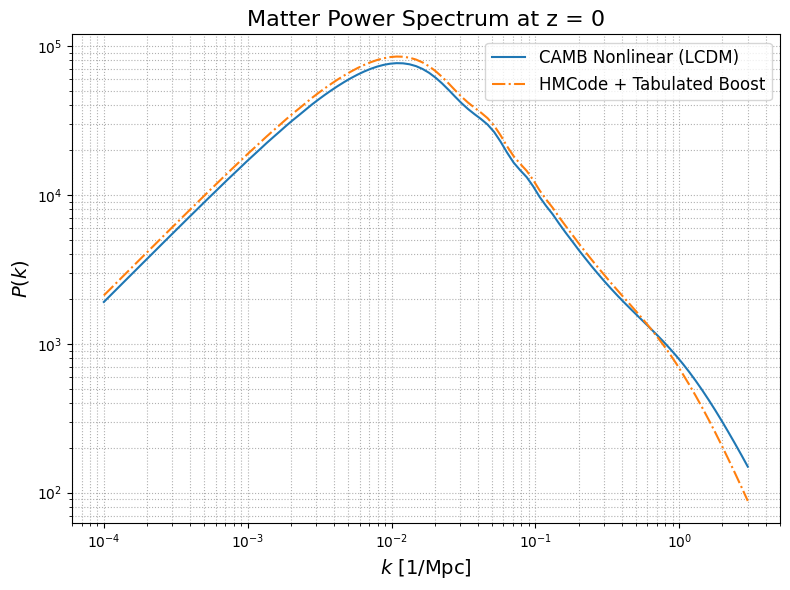

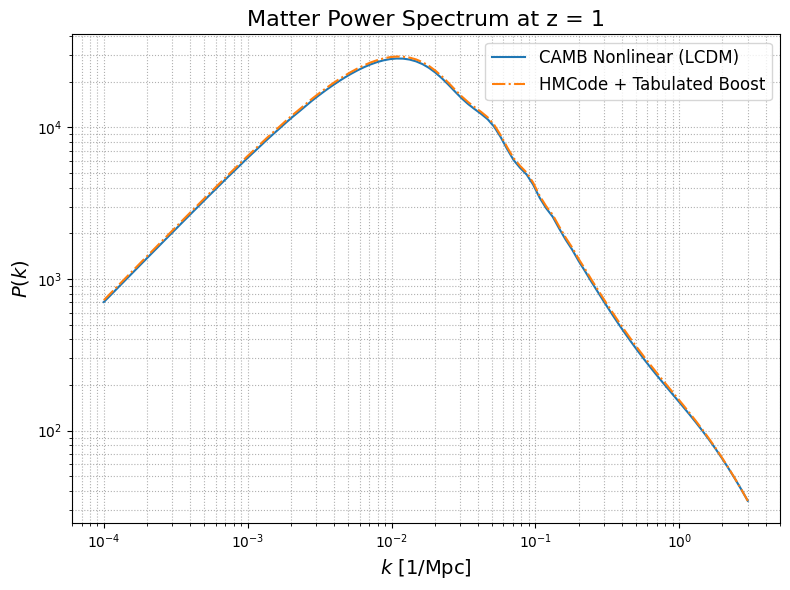

In [5]:
# Plotting
for i, z in enumerate(myz):
    plt.figure(figsize=(8, 6))
    
    plt.loglog(ks, nonlinear_pk_hmc_lcdm[i], label='CAMB Nonlinear (LCDM)', linestyle='solid')
    plt.loglog(ks, nonlinear_pk_hmc_tabulated[i], label='HMCode + Tabulated Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P(k)$', fontsize=14)
    plt.title(f'Matter Power Spectrum at z = {z}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

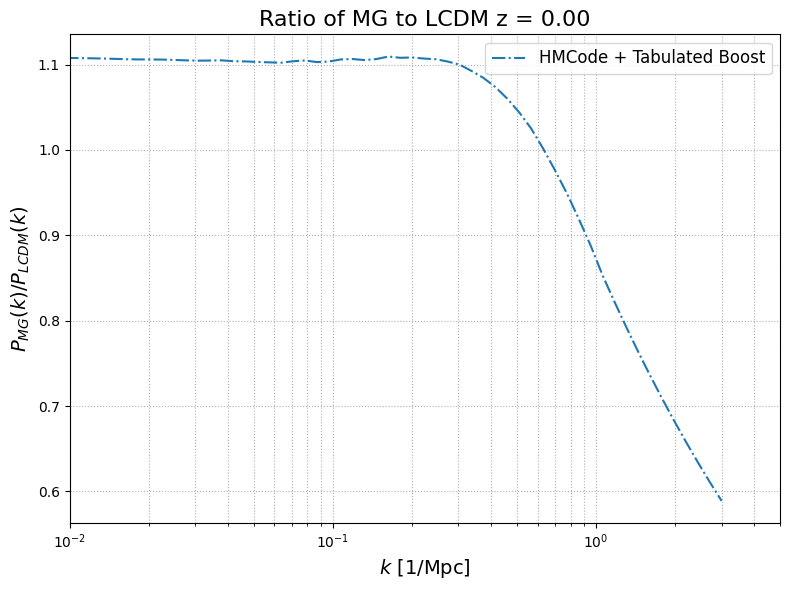

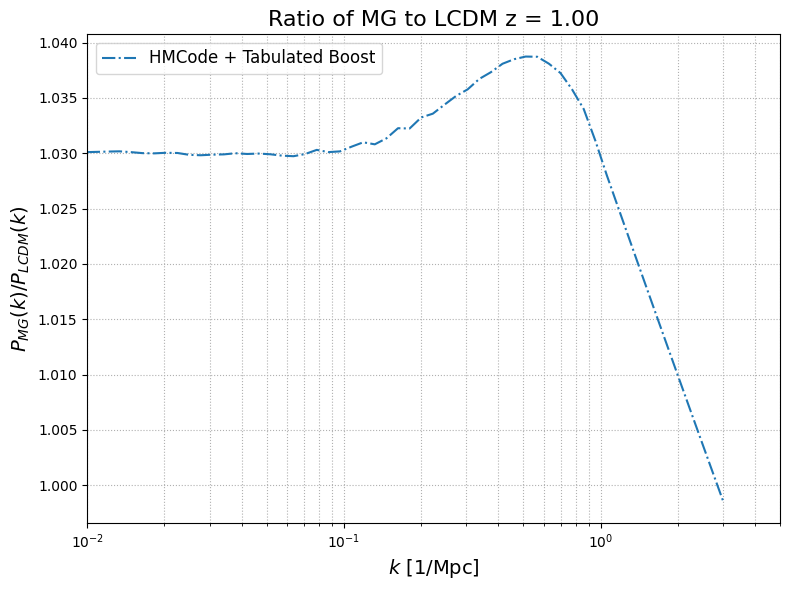

In [6]:
for i, z in enumerate(myz):
    plt.figure(figsize=(8, 6))
    plt.semilogx(ks, nonlinear_pk_hmc_tabulated[i]/nonlinear_pk_hmc_lcdm[i], label='HMCode + Tabulated Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 5)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

# Test extrapolation 

In [6]:
ks_ex = np.logspace(np.log10(1e-4), np.log10(10), 200)
myz_ex = [0,2,30]

In [8]:
# Compute power spectra
nonlinear_pk_hmc_lcdm_ex = nonlinear_perturbations_hmc.matter_power_spectrum(myz_ex, ks_ex)
nonlinear_pk_hmc_tabulated_ex = boosted_perturbations_hmc_tab.matter_power_spectrum(myz_ex, ks_ex)


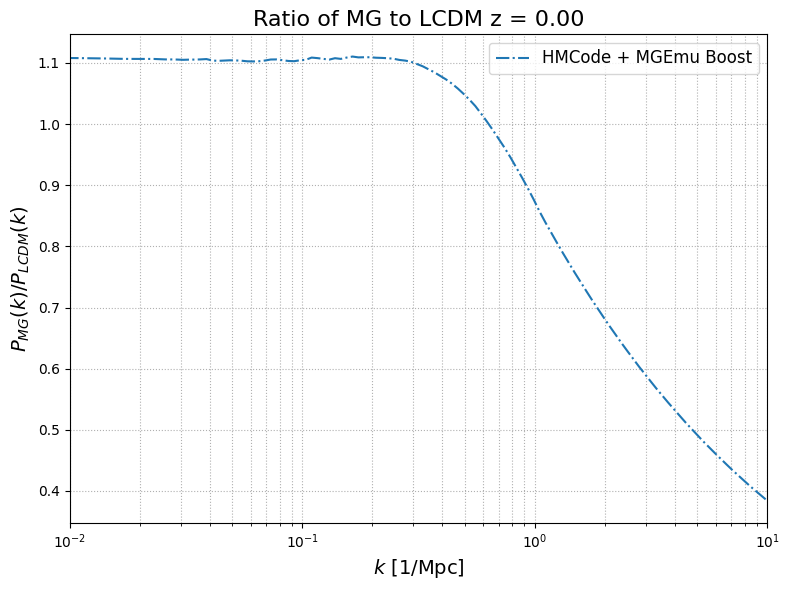

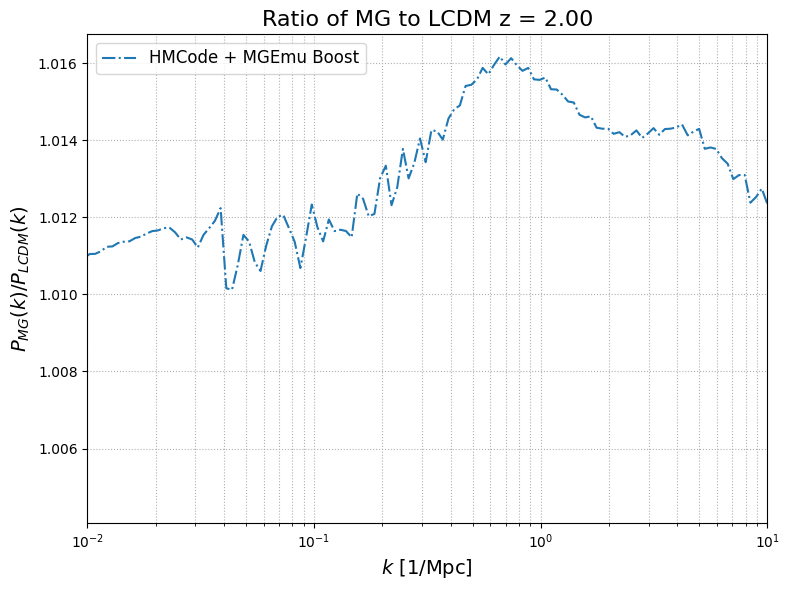

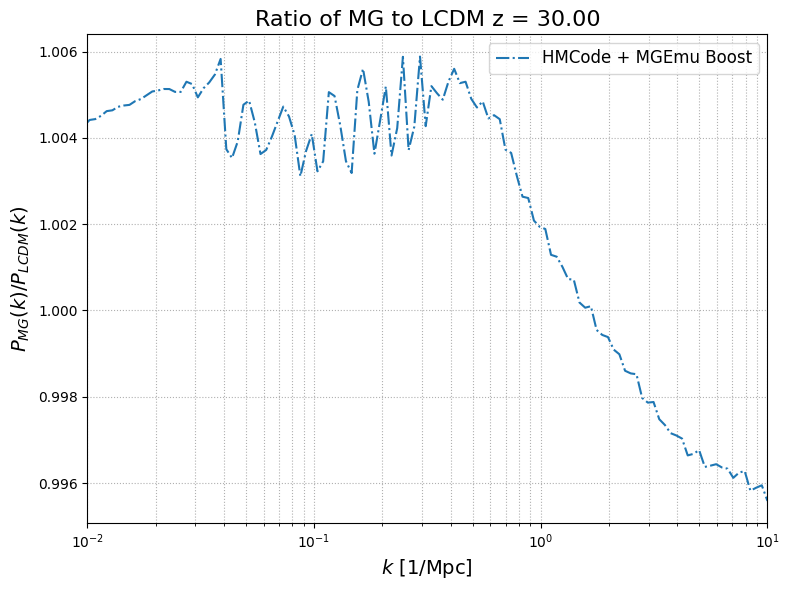

In [9]:
for i, z in enumerate(myz_ex):
    plt.figure(figsize=(8, 6))
    plt.semilogx(ks_ex, nonlinear_pk_hmc_tabulated_ex[i]/nonlinear_pk_hmc_lcdm_ex[i], label='HMCode + MGEmu Boost', linestyle='dashdot')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 10)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

# Compare to Halo Model Reaction boost using ReACTEmu_cosmology module

In [7]:
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

/opt/anaconda3/envs/mgemu_env/lib/python3.10/site-packages/MGEmu


In [72]:
# Model of gravity or dark energy settings
# Which model? 
gravity_model = 'ide'

# Provide all expected keys, with harmless defaults for unused ones
mgpars = {
    "fr0": 0.0,
    "omega_rc": 0.0,   # only used for DGP
    "xi": xi,          # Used for all DS cases
    "gamma0": 0.55,    # only used for Linder gamma
    "q1": 0.0          # placeholder, adjust if needed
}

# Initialise w0wacdm background 
ds_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0ds, wa=wads, 
                               gamma_MG=0.0)

# Create the nonlinear MG boost
mg_boost_react = MGemuNonlinearBoost(ds_instance,linear_perturbations_camb, zs, gravity_model, mgpars, high_z_policy='one')
boost_interp_react = mg_boost_react.MGboost_interp

# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_react = BoostedPerturbations(linear_perturbations_camb, nonlinear_perturbations_hmc, boost_interp_react)

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


In [83]:
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)
myz = [0,1]

# Compute power spectra
nonlinear_pk_hmc_lcdm = nonlinear_perturbations_hmc.matter_power_spectrum(myz, ks)
nonlinear_pk_hmc_tabulated = boosted_perturbations_hmc_tab.matter_power_spectrum(myz, ks)
nonlinear_pk_hmc_react = boosted_perturbations_hmc_react.matter_power_spectrum(myz, ks)

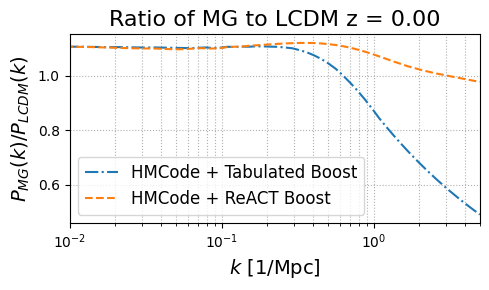

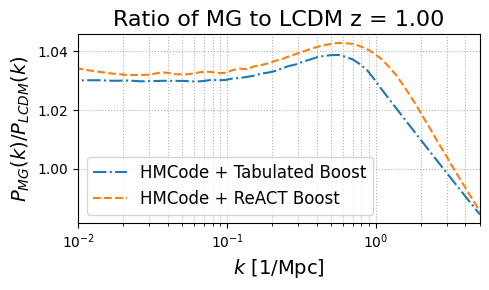

In [84]:
for i, z in enumerate(myz):
    plt.figure(figsize=(5, 3))
    plt.semilogx(ks, nonlinear_pk_hmc_tabulated[i]/nonlinear_pk_hmc_lcdm[i], label='HMCode + Tabulated Boost', linestyle='dashdot')
    plt.semilogx(ks, nonlinear_pk_hmc_react[i]/nonlinear_pk_hmc_lcdm[i], label='HMCode + ReACT Boost', linestyle='dashed')

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 5)
    # plt.ylim(0.85,1.15)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

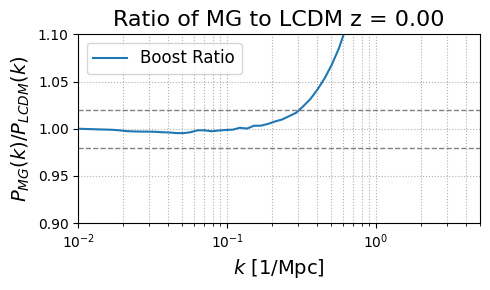

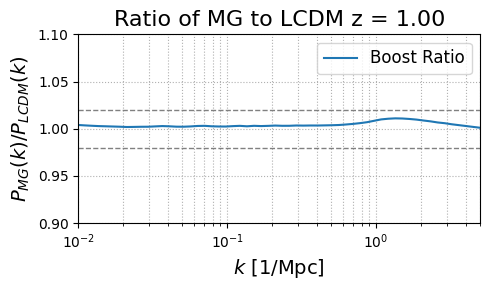

In [85]:
for i, z in enumerate(myz):
    plt.figure(figsize=(5, 3))
    plt.semilogx(ks, nonlinear_pk_hmc_react[i]/nonlinear_pk_hmc_tabulated[i], label='Boost Ratio', linestyle='solid')
       
    # --- 2% bands ---
    plt.axhline(1.02, color='gray', linestyle='--', linewidth=1)
    plt.axhline(0.98, color='gray', linestyle='--', linewidth=1)

    plt.xlabel(r'$k$ [1/Mpc]', fontsize=14)
    plt.ylabel(r'$P_{MG}(k)/P_{LCDM}(k)$', fontsize=14)
    plt.xlim(1e-2, 5)
    plt.ylim(0.9,1.1)
    plt.title(f'Ratio of MG to LCDM z = {z:.2f}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()